Deeltaak 3

In [172]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from prophet import Prophet

df = pd.read_excel('../../Data/raw/dataset.xlsx')

df.head()


,vestnr,postcode,plaats,gemeente_code,datum_start,datum_einde,jaar,man_fte,vrouw_fte,man_pte,vrouw_pte,wp,sector_code,sbi_code,rechtsvorm,rechtsvorm_code,bagoppervlak
0,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2015,2,2,0,0,4,A,1241,Besloten Vennootschap (BV),41.0,166.0
1,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2016,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
2,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2017,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
3,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2018,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
4,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2019,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0


In [173]:
df_filtered = df[['vestnr', 'jaar', 'postcode', 'datum_start', 'datum_einde', 'wp', 'sector_code', 'sbi_code']]
df_filtered.head()

,vestnr,jaar,postcode,datum_start,datum_einde,wp,sector_code,sbi_code
0,19593363327,2015,3897LL,2009-01-01 00:00:00,NaT,4,A,1241
1,19593363327,2016,3897LL,2009-01-01 00:00:00,NaT,2,A,1241
2,19593363327,2017,3897LL,2009-01-01 00:00:00,NaT,2,A,1241
3,19593363327,2018,3897LL,2009-01-01 00:00:00,NaT,2,A,1241
4,19593363327,2019,3897LL,2009-01-01 00:00:00,NaT,2,A,1241


In [174]:
sector_map = {
    'A': 'Landbouw, bosbouw en visserij',
    'B': 'Winning van delfstoffen',
    'C': 'Industrie',
    'D': 'Energievoorziening',
    'E': 'Water en afvalbeheer',
    'F': 'Bouwnijverheid',
    'G': 'Handel en reparatie van auto’s',
    'H': 'Vervoer en opslag',
    'I': 'Horeca',
    'J': 'Informatie en communicatie',
    'K': 'Financiële instellingen',
    'L': 'Verhuur en handel van onroerend goed',
    'M': 'Zakelijke dienstverlening',
    'N': 'Overige zakelijke dienstverlening',
    'O': 'Openbaar bestuur',
    'P': 'Onderwijs',
    'Q': 'Gezondheidszorg',
    'R': 'Cultuur, sport en recreatie',
    'S': 'Overige dienstverlening'
}

df_filtered['sector_code'] = df_filtered['sector_code'].map(sector_map)
df_filtered.head()

C:\Users\bokul\AppData\Local\Temp\ipykernel_13472\1141495402.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['sector_code'] = df_filtered['sector_code'].map(sector_map)


,vestnr,jaar,postcode,datum_start,datum_einde,wp,sector_code,sbi_code
0,19593363327,2015,3897LL,2009-01-01 00:00:00,NaT,4,"Landbouw, bosbouw en visserij",1241
1,19593363327,2016,3897LL,2009-01-01 00:00:00,NaT,2,"Landbouw, bosbouw en visserij",1241
2,19593363327,2017,3897LL,2009-01-01 00:00:00,NaT,2,"Landbouw, bosbouw en visserij",1241
3,19593363327,2018,3897LL,2009-01-01 00:00:00,NaT,2,"Landbouw, bosbouw en visserij",1241
4,19593363327,2019,3897LL,2009-01-01 00:00:00,NaT,2,"Landbouw, bosbouw en visserij",1241


In [175]:
df_aantal = df_filtered.groupby(['sector_code','jaar']).size().reset_index(name='aantal')

df_wp = df_filtered.groupby(['sector_code','jaar'])['wp'].sum().reset_index(name='wp')

df_yearly = df_aantal.merge(df_wp, on=['sector_code','jaar'])

df_pivot = df_yearly.pivot(index='sector_code', columns='jaar', values=['aantal','wp'])

df_pivot.columns = [f"{val}_{jaar}" for val, jaar in df_pivot.columns]

wp_cols = [col for col in df_pivot.columns if col.startswith('wp_')]

df_pivot[wp_cols] = df_pivot[wp_cols].fillna(0)

aantal_cols = [col for col in df_pivot.columns if col.startswith('aantal_')]

df_pivot[aantal_cols] = df_pivot[aantal_cols].fillna(0)

df_pivot['verschil_aantal'] = df_pivot['aantal_2024'] - df_pivot['aantal_2014']
df_pivot['pct_groei_aantal'] = (df_pivot['aantal_2024'] - df_pivot['aantal_2014']) / df_pivot['aantal_2014'] * 100

df_pivot['verschil_wp'] = df_pivot['wp_2024'] - df_pivot['wp_2014']
df_pivot['pct_groei_wp'] = (df_pivot['wp_2024'] - df_pivot['wp_2014']) / df_pivot['wp_2014'] * 100

df_pivot.reset_index(inplace=True)
df_pivot

,sector_code,aantal_2014,aantal_2015,aantal_2016,aantal_2017,aantal_2018,aantal_2019,aantal_2020,aantal_2021,aantal_2022,...,wp_2019,wp_2020,wp_2021,wp_2022,wp_2023,wp_2024,verschil_aantal,pct_groei_aantal,verschil_wp,pct_groei_wp
0,Bouwnijverheid,598.0,575.0,570.0,563.0,575.0,592.0,630.0,660.0,702.0,...,4852.0,5028.0,5008.0,5140.0,5400.0,5706.0,189.0,31.605351,1446.0,33.943662
1,"Cultuur, sport en recreatie",293.0,301.0,301.0,307.0,317.0,466.0,416.0,387.0,379.0,...,3419.0,3414.0,2961.0,3147.0,3326.0,3694.0,97.0,33.105802,662.0,21.833773
2,Energievoorziening,14.0,18.0,17.0,16.0,15.0,15.0,14.0,13.0,18.0,...,227.0,160.0,161.0,280.0,302.0,323.0,4.0,28.571429,72.0,28.685259
3,Financiële instellingen,142.0,133.0,121.0,110.0,108.0,112.0,112.0,106.0,106.0,...,1085.0,1087.0,1030.0,959.0,972.0,682.0,-32.0,-22.535211,-875.0,-56.197816
4,Gezondheidszorg,1246.0,1168.0,1145.0,1127.0,1166.0,1255.0,1251.0,1288.0,1282.0,...,22709.0,23544.0,24898.0,25290.0,25921.0,26993.0,131.0,10.513644,3588.0,15.330058
5,Handel en reparatie van auto’s,3136.0,3042.0,2951.0,2908.0,2955.0,3422.0,3553.0,3733.0,3848.0,...,34876.0,35836.0,36901.0,37923.0,38383.0,39239.0,556.0,17.729592,7764.0,24.667196
6,Horeca,590.0,588.0,603.0,634.0,664.0,747.0,762.0,782.0,778.0,...,7951.0,7500.0,7072.0,7345.0,7504.0,7765.0,151.0,25.593220,1814.0,30.482272
7,Industrie,680.0,663.0,677.0,686.0,684.0,690.0,700.0,695.0,701.0,...,16136.0,16167.0,16201.0,16658.0,17292.0,17479.0,64.0,9.411765,3873.0,28.465383
8,Informatie en communicatie,533.0,508.0,515.0,496.0,510.0,492.0,494.0,499.0,527.0,...,4003.0,3922.0,4000.0,4103.0,4265.0,4248.0,1.0,0.187617,-1813.0,-29.912556
9,"Landbouw, bosbouw en visserij",1350.0,1333.0,1346.0,1323.0,1353.0,1371.0,1368.0,1386.0,1378.0,...,5307.0,5326.0,5296.0,5113.0,5176.0,5177.0,-19.0,-1.407407,124.0,2.453988


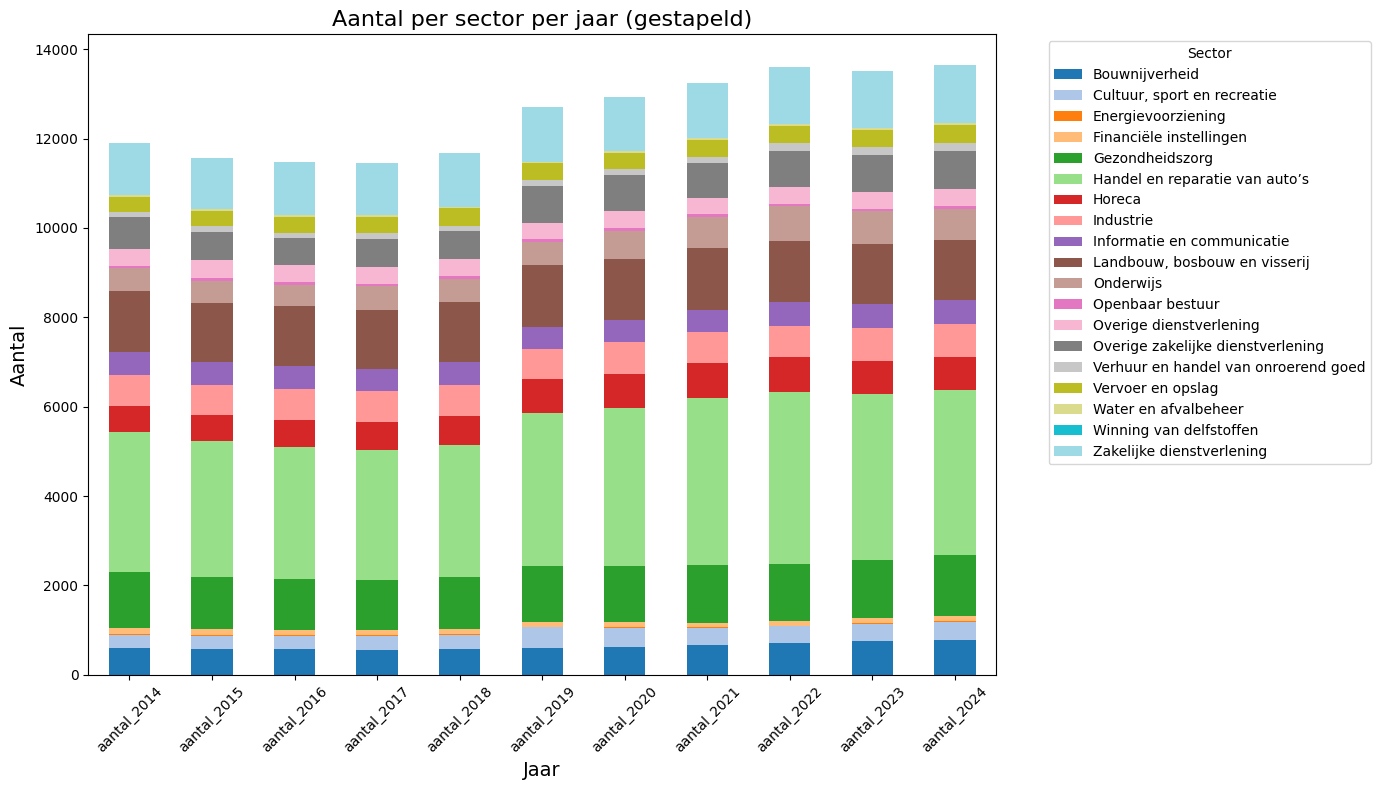

In [176]:
aantal_cols = [col for col in df_pivot.columns if col.startswith('aantal_')]

df_pivot[aantal_cols].T.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap='tab20'
)

plt.title('Aantal per sector per jaar (gestapeld)', fontsize=16)
plt.xlabel('Jaar', fontsize=14)
plt.ylabel('Aantal', fontsize=14)
plt.xticks(rotation=45)

plt.legend(df_pivot['sector_code'], title='Sector', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

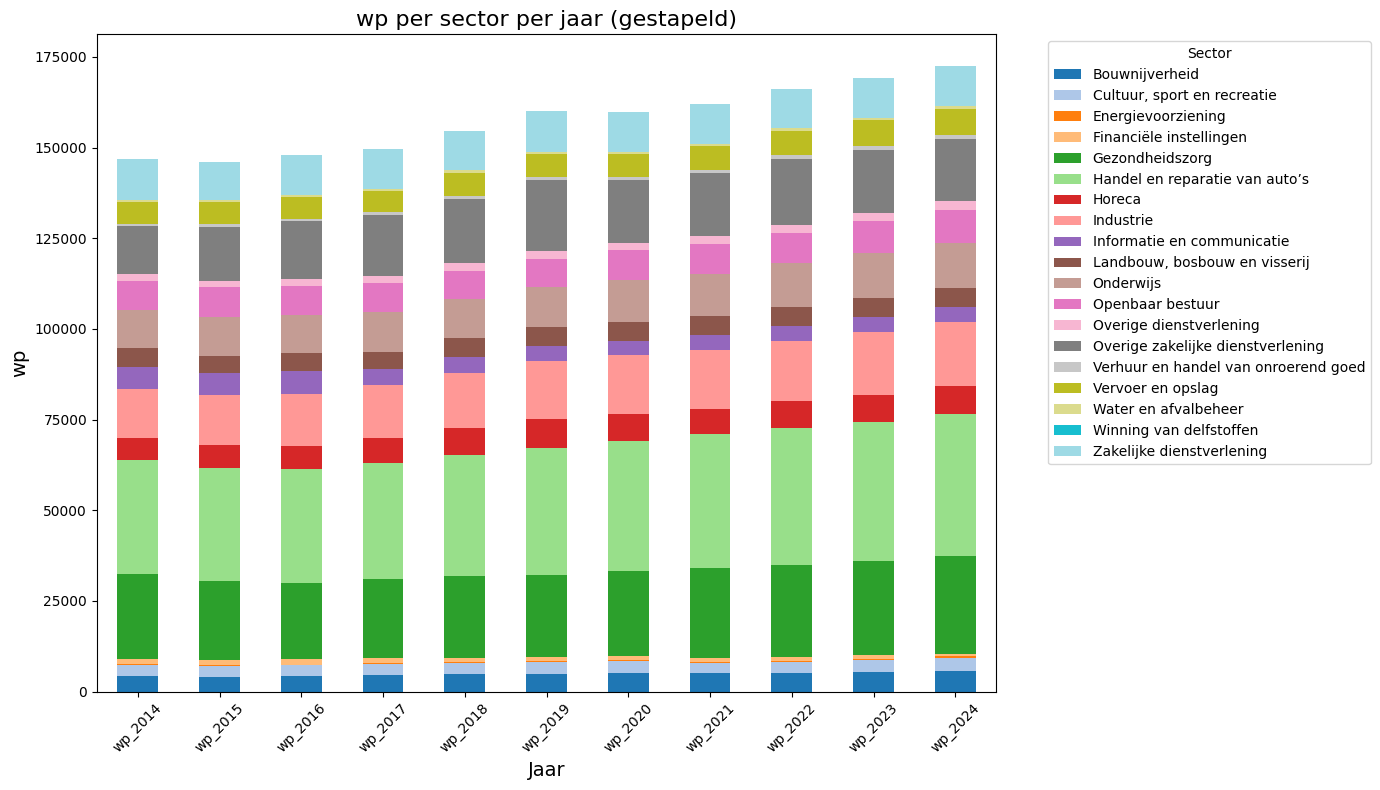

In [177]:
wp_cols = [col for col in df_pivot.columns if col.startswith('wp_')]

df_pivot[wp_cols].T.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap='tab20'
)

plt.title('wp per sector per jaar (gestapeld)', fontsize=16)
plt.xlabel('Jaar', fontsize=14)
plt.ylabel('wp', fontsize=14)
plt.xticks(rotation=45)

plt.legend(df_pivot['sector_code'], title='Sector', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

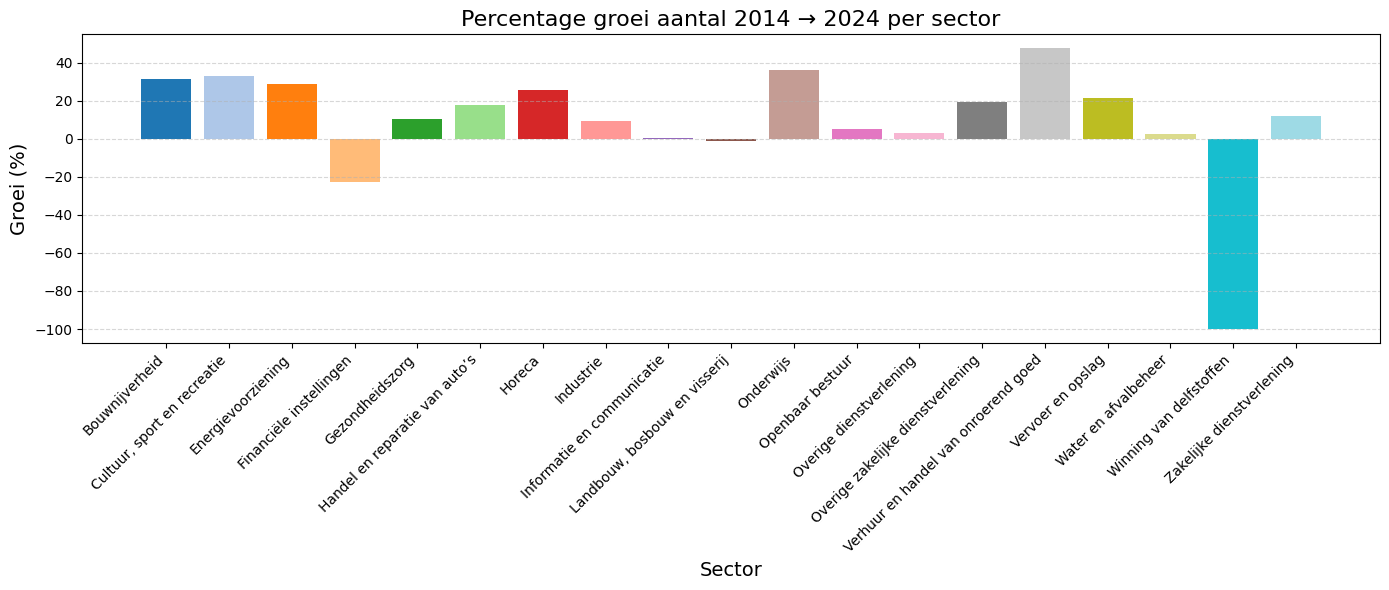

In [178]:
n_sectors = len(df_pivot)

colors = cm.tab20(np.linspace(0, 1, n_sectors))

plt.figure(figsize=(14,6))
plt.bar(df_pivot['sector_code'], df_pivot['pct_groei_aantal'], color=colors)
plt.title('Percentage groei aantal 2014 → 2024 per sector', fontsize=16)
plt.xlabel('Sector', fontsize=14)
plt.ylabel('Groei (%)', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

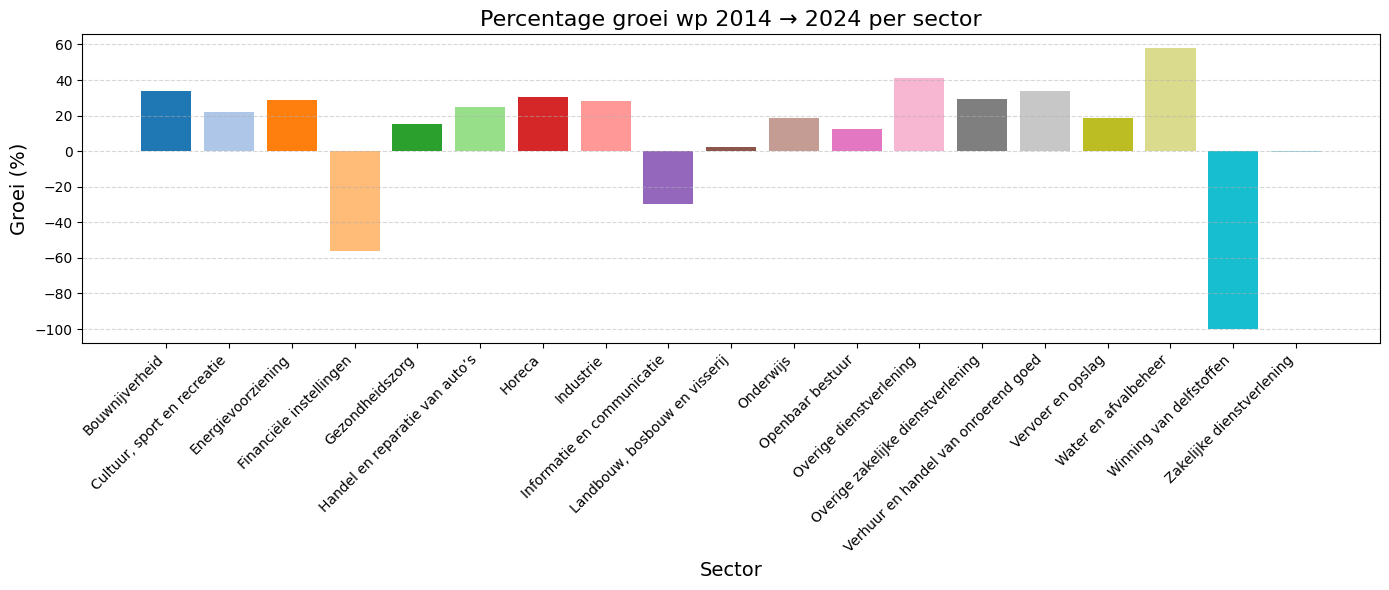

In [179]:
n_sectors = len(df_pivot)

colors = cm.tab20(np.linspace(0, 1, n_sectors))

plt.figure(figsize=(14,6))
plt.bar(df_pivot['sector_code'], df_pivot['pct_groei_wp'], color=colors)
plt.title('Percentage groei wp 2014 → 2024 per sector', fontsize=16)
plt.xlabel('Sector', fontsize=14)
plt.ylabel('Groei (%)', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [180]:
def prepare_prophet_df(df, sector):
    df_sector = df[df['sector_code']==sector].copy()
    
    jaren = range(2014, 2025)
    data = {
        'ds': [],
        'y': [],
        'wp': []
    }
    
    for jaar in jaren:
        data['ds'].append(pd.to_datetime(str(jaar)))
        data['y'].append(df_sector[f'aantal_{jaar}'].values[0])
        data['wp'].append(df_sector[f'wp_{jaar}'].values[0])
    
    df_long = pd.DataFrame(data)
    return df_long

all_forecasts = []

for sector in df_pivot['sector_code']:

    df_prophet = prepare_prophet_df(df_pivot, sector)

    model = Prophet(yearly_seasonality=False)
    model.add_regressor('wp')
    model.fit(df_prophet[['ds','y','wp']])

    future = model.make_future_dataframe(periods=10, freq='Y')
    
    existing_wp = df_prophet['wp'].values
    wp_slope = (existing_wp[-1] - existing_wp[0]) / (2024 - 2014)
    future_wp = [existing_wp[-1] + wp_slope*(i+1) for i in range(10)]
    future['wp'] = np.concatenate([existing_wp, future_wp])
    
    forecast = model.predict(future)
    forecast['sector_code'] = sector
    forecast['yhat'] = forecast['yhat'].apply(lambda x: max(round(x), 0))

    all_forecasts.append(forecast[['ds','yhat','sector_code']])

df_forecast_all = pd.concat(all_forecasts).reset_index(drop=True)

df_forecast_all

03:57:39 - cmdstanpy - INFO - Chain [1] start processing
03:57:39 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\bokul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
03:57:39 - cmdstanpy - INFO - Chain [1] start processing
03:57:39 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\bokul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
03:57:39 - cmdstanpy - INFO - Chain [1] start processing
03:57:39 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\bokul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5

,ds,yhat,sector_code
0,2014-01-01,552,Bouwnijverheid
1,2015-01-01,542,Bouwnijverheid
2,2016-01-01,560,Bouwnijverheid
3,2017-01-01,591,Bouwnijverheid
4,2018-01-01,623,Bouwnijverheid
...,...,...,...
394,2029-12-31,1438,Zakelijke dienstverlening
395,2030-12-31,1460,Zakelijke dienstverlening
396,2031-12-31,1482,Zakelijke dienstverlening
397,2032-12-31,1504,Zakelijke dienstverlening


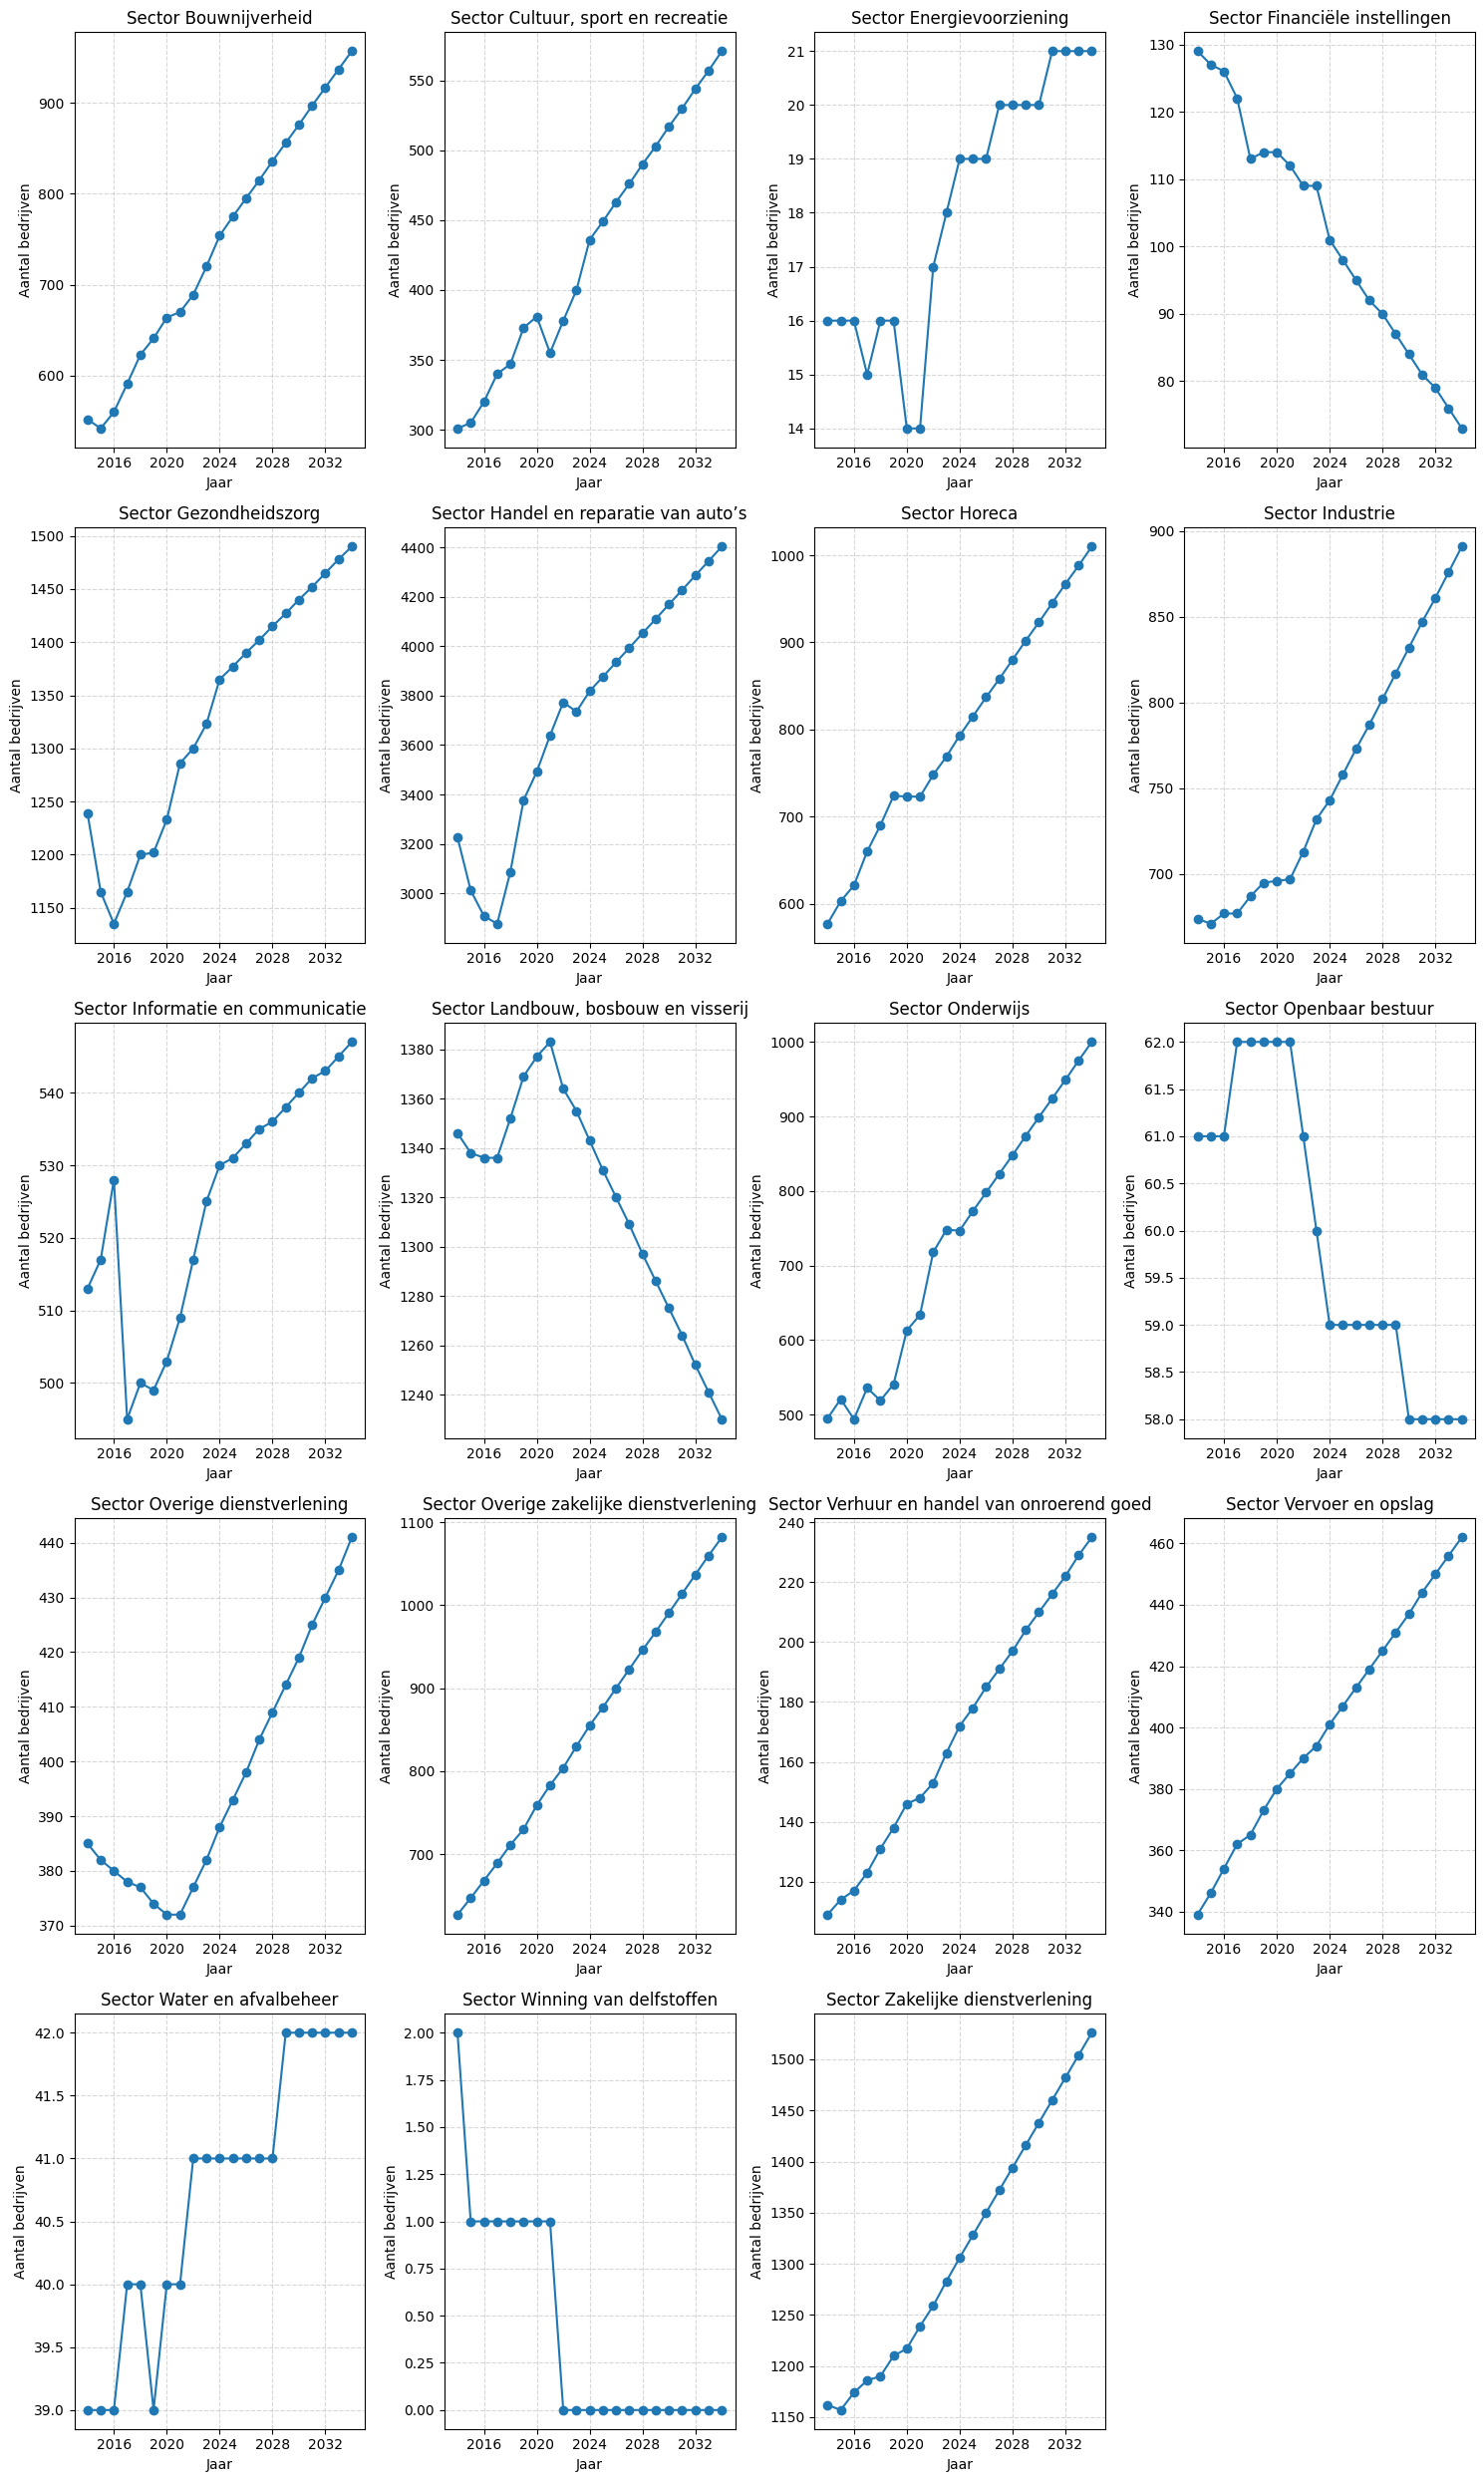

In [181]:
sectoren = df_forecast_all['sector_code'].unique()
n_sectors = len(sectoren)

cols = 4
rows = (n_sectors + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for i, sector in enumerate(sectoren):
    df_plot = df_forecast_all[df_forecast_all['sector_code'] == sector]
    axes[i].plot(df_plot['ds'], df_plot['yhat'], marker='o')
    axes[i].set_title(f'Sector {sector}')
    axes[i].set_xlabel('Jaar')
    axes[i].set_ylabel('Aantal bedrijven')
    axes[i].grid(True, linestyle='--', alpha=0.5)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()